# Flight mechanincs 2 : Phase 1
##### ✅Groupe name = ✈️ <br>
##### ✅Groupe members = <b> Seyed Mani Seyed SalehiZadeh, Sarah Barati, Arshia Alizadeh </b>
##### ✅Aircraft selected : Charlie 1

---



### Loading the simulation setup + dependencies

In [1]:
import numpy as np
from pysim.Simulator import load
from pysim.Visualize import ResponsePlotter, Position2D, Position3D
import matplotlib.pyplot as plt
from scipy.signal import ss2tf
sim2 = load()


### System analysis
Finding the eigenvalue of the system to see if it stable or not

In [2]:
print("Eigen values of the latitudal system matrix:")
print(np.linalg.eigvals(sim2.A_lat))

print("---------------------------------------------")

print("Eigen values of the longitudal system matrix:")
print(np.linalg.eigvals(sim2.A_long))

Eigen values of the latitudal system matrix:
[-0.089       0.          0.         -0.90297914 -0.29794964]
---------------------------------------------
Eigen values of the longitudal system matrix:
[ 6.66367265e+01 -4.48307089e-01 -7.56120471e-02 -3.60734324e-03]


## Finding the transfer functions of the system
⚠️Expand the results to see all of the transfer functions

In [3]:
sim2.getTF()

H_v_Aileron(s) = 
                             4                     3                     2    
       1.11022302462516e-15⋅s  - 2.04549749764522⋅s  + 3.18586915050156⋅s  + 0
H(s) = ───────────────────────────────────────────────────────────────────────
                   5                     4                      3             
              1.0⋅s  + 1.28992877946723⋅s  + 0.375924973522352⋅s  + 0.02394476

                  
.574389619948086⋅s
──────────────────
          2       
57813294⋅s        
H_v_Rudder(s) = 
                             4                     3                   2      
       3.10862446895044e-15⋅s  + 9.98186085778902⋅s  + 11.30741309525⋅s  - 0.3
H(s) = ───────────────────────────────────────────────────────────────────────
                  5                     4                      3              
             1.0⋅s  + 1.28992877946723⋅s  + 0.375924973522352⋅s  + 0.023944765

                
34921553526951⋅s
────────────────
         2      
7813294⋅s 

### Control inputs and the simulation settings

In [4]:
#The inputs of the simulation
X0 = np.array([0,0,0,0,0,0,0,0,0])
timeStep = 0.001 

defR = lambda x, t: 0
defE = lambda x, t: 1/timeStep if 0 <= t < timeStep else 0  #Impulse function 
defA = lambda x, t: 0
defTh = lambda x, t: 0

In [5]:
solution, sol_long, sol_lat = sim2.LinearSim(defR, defE, defA, defTh, X0,  timeStep=timeStep, simFinalTime=0.9,  simStartTime=0)

### Plotting the response of the system

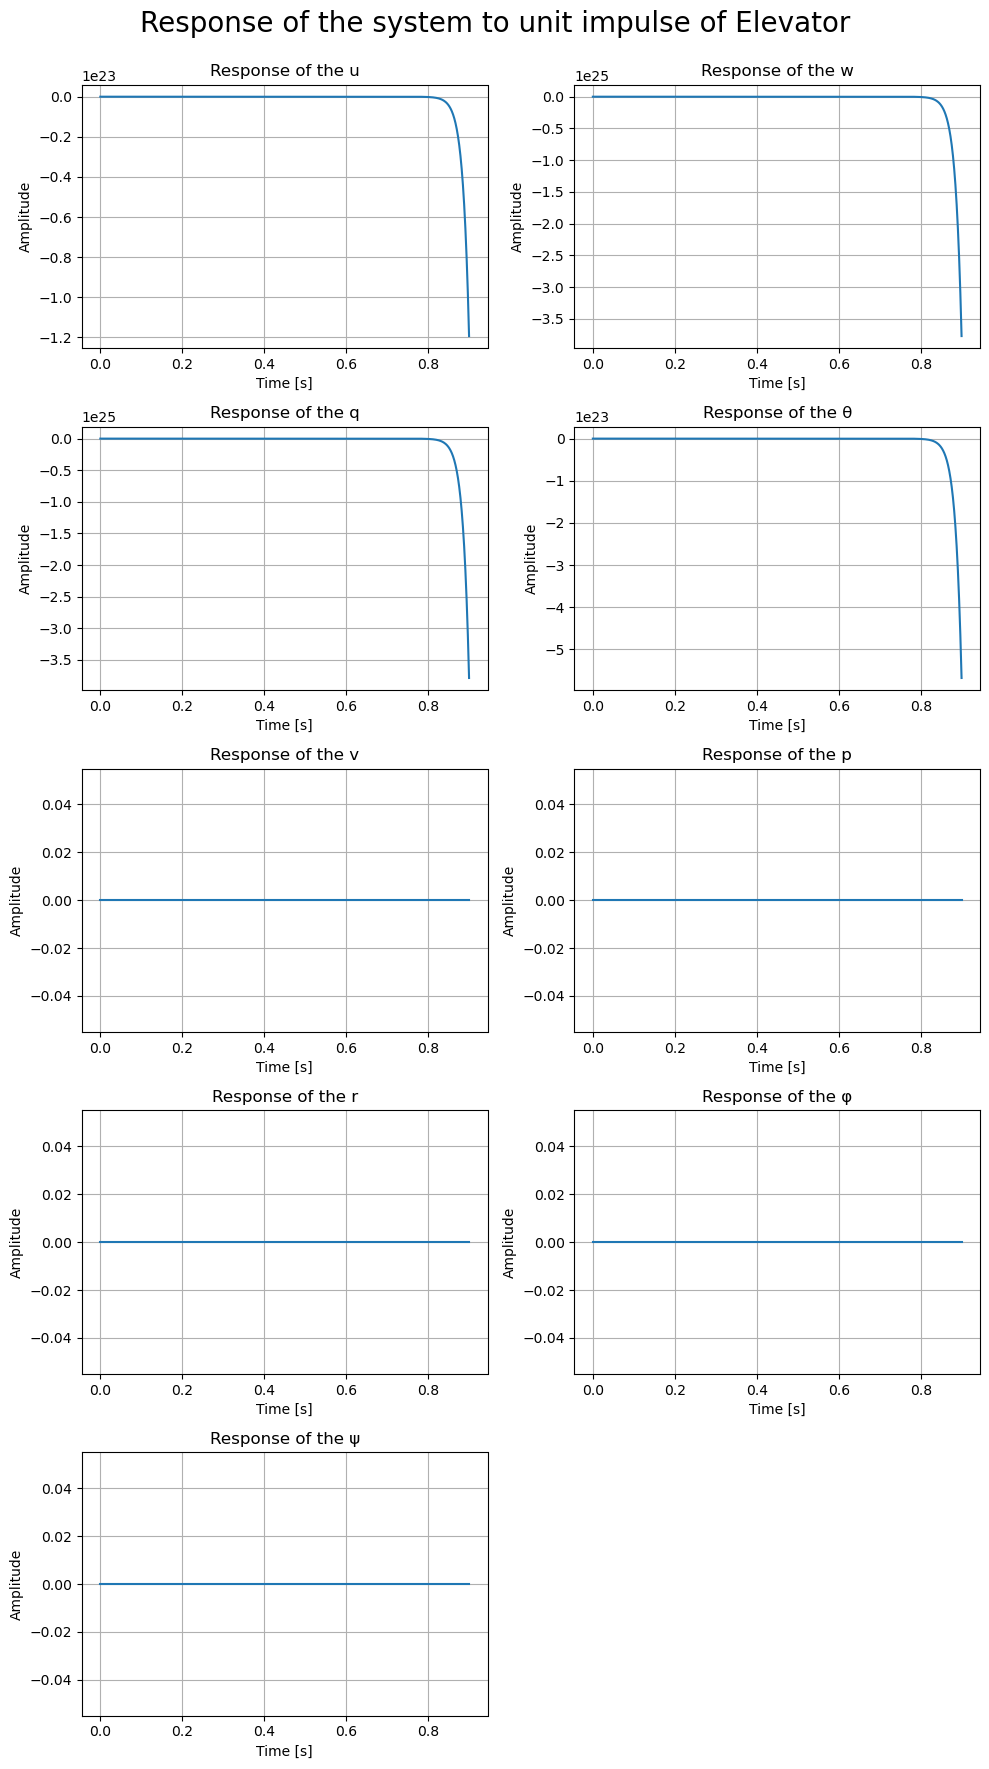

In [6]:
ResponsePlotter(solution=solution, title="Response of the system to unit impulse of Elevator")

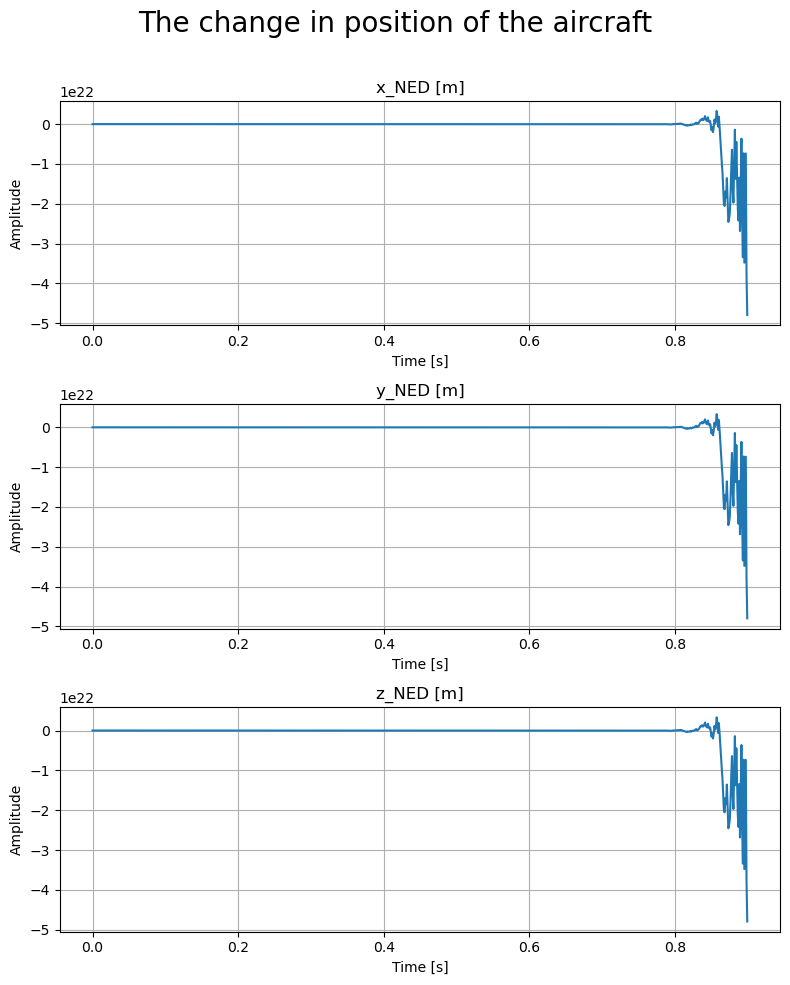

In [7]:
Position2D(solution=solution, title="The change in position of the aircraft")

In [8]:
Position3D(solution=solution)

----------

## Additional plots (Just in case the above charts are too small)

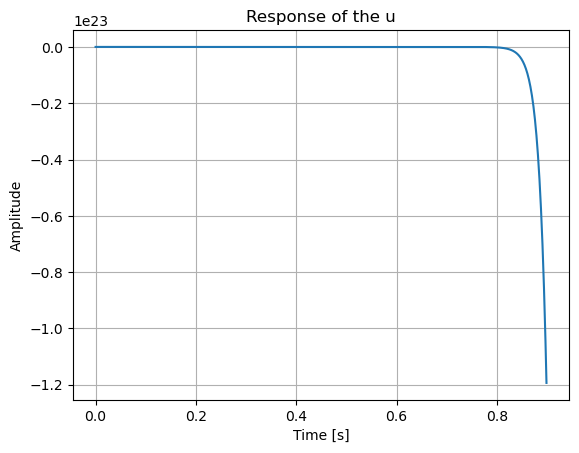

In [9]:
plt.plot(solution["times"], solution["states"][:,0])
plt.title("Response of the u")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()


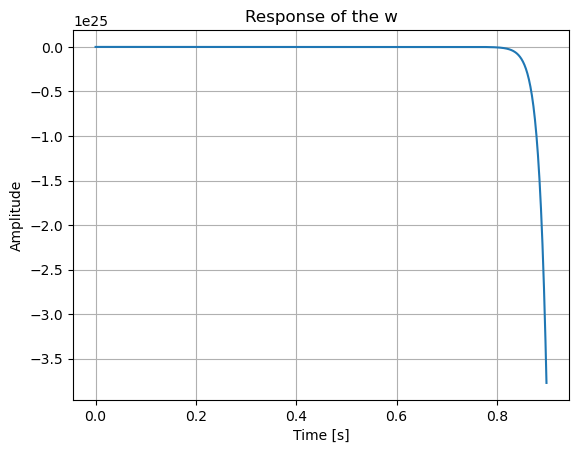

In [10]:

plt.plot(solution["times"], solution["states"][:,1])
plt.title("Response of the w")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

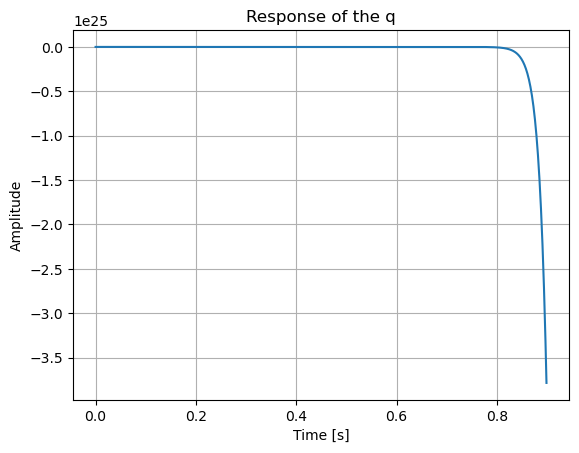

In [11]:
plt.plot(solution["times"], solution["states"][:,2])
plt.title("Response of the q")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

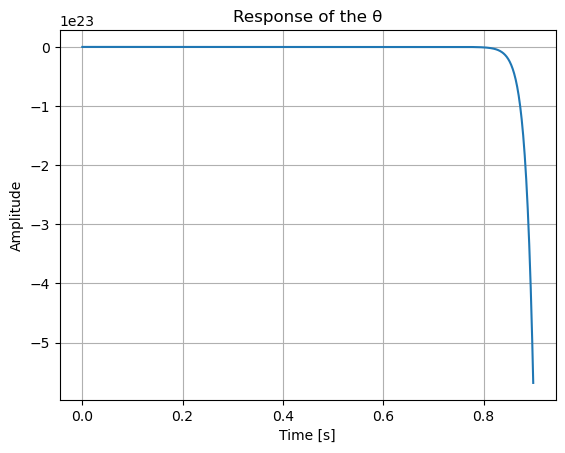

In [12]:
plt.plot(solution["times"], solution["states"][:,3])
plt.title("Response of the θ")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

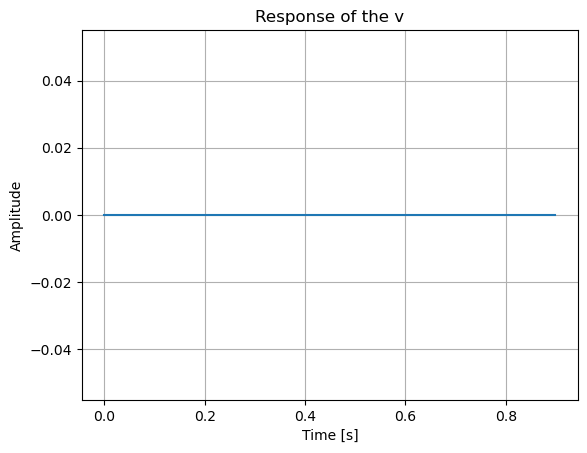

In [13]:
plt.plot(solution["times"], solution["states"][:,4])
plt.title("Response of the v")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

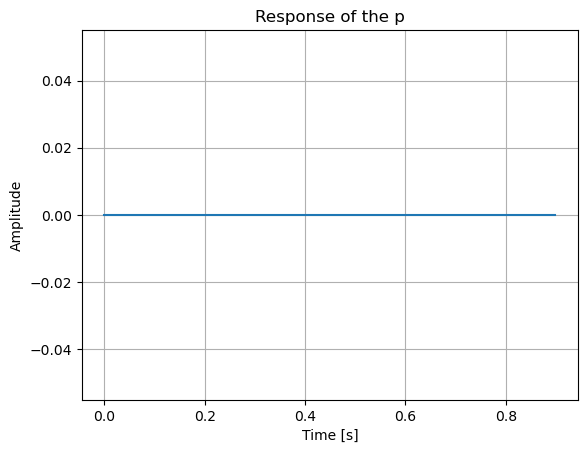

In [14]:
plt.plot(solution["times"], solution["states"][:,5])
plt.title("Response of the p")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

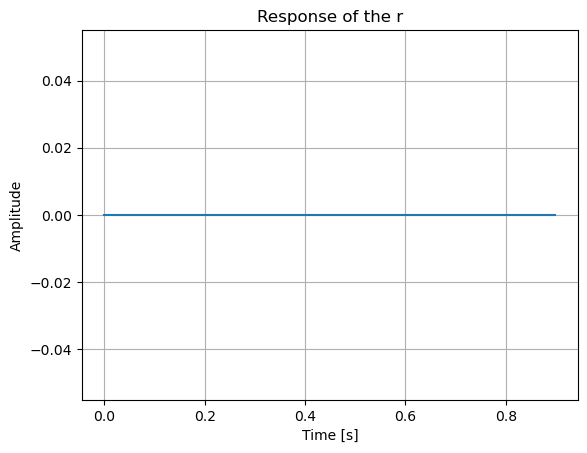

In [15]:
plt.plot(solution["times"], solution["states"][:,6])
plt.title("Response of the r")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

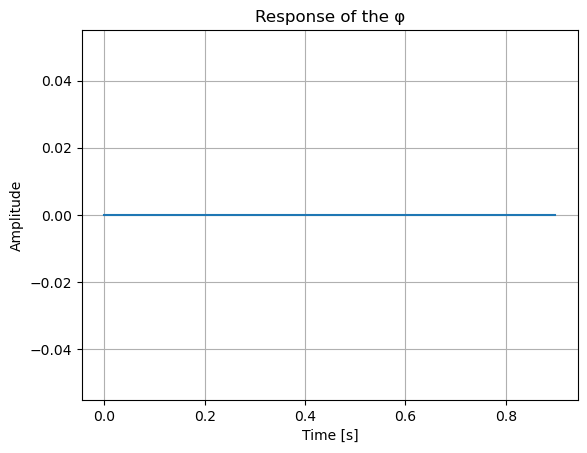

In [16]:
plt.plot(solution["times"], solution["states"][:,7])
plt.title("Response of the φ")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

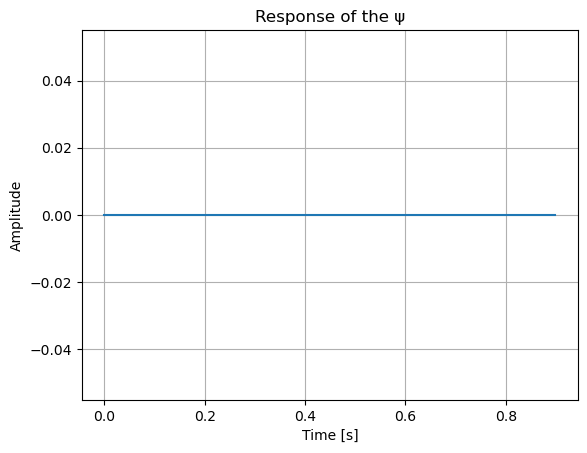

In [17]:
plt.plot(solution["times"], solution["states"][:,8])
plt.title("Response of the ψ")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

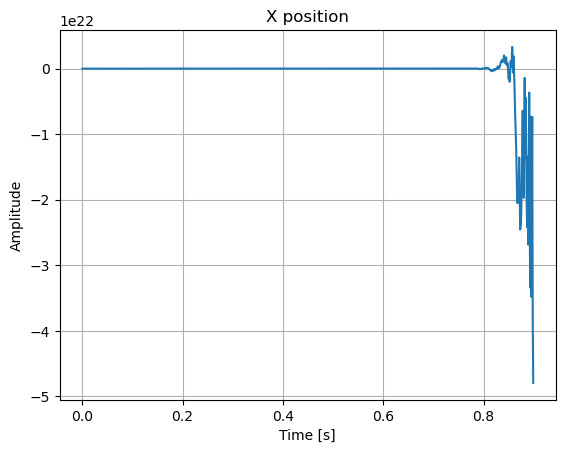

In [18]:
# Plotting the position of aircraft over time 
plt.plot(solution["times"], solution["positions"][:,0])
plt.title("X position")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()


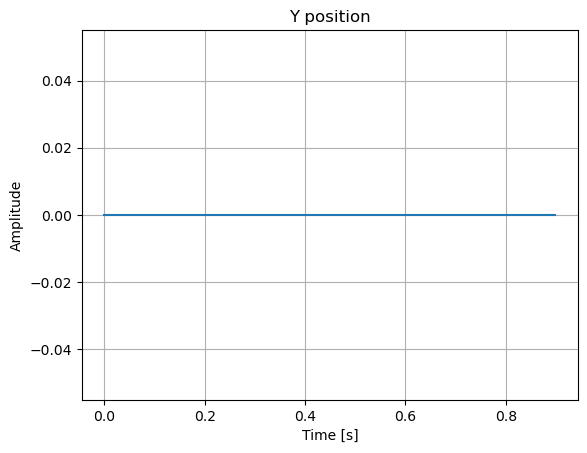

In [19]:
# Plotting the position of aircraft over time 
plt.plot(solution["times"], solution["positions"][:,1])
plt.title("Y position")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()

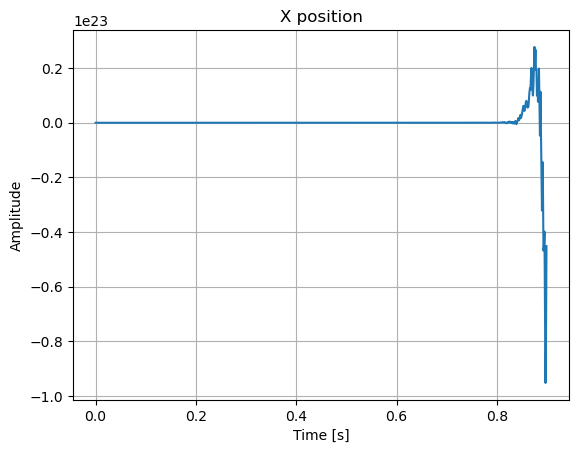

In [20]:
# Plotting the position of aircraft over time 
plt.plot(solution["times"], solution["positions"][:,2])
plt.title("X position")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()
